# 07. 절대 밴드는 수준을 필요로 한다 — 전처리 후보 다섯을 재 보다

> 2026-09-09 · 이동원 · 이슈 [#214](https://github.com/devlee328288/Alpha_Stack/issues/214) ·
> 전처리 [v1.2 명세서](../../docs/전처리/version1.2/전처리-설계-명세서.md)

---

## 이 노트북이 답하는 것

> **퀀트 표준대로 만든 횡단면 전처리가 왜 우리 모델을 나쁘게 만들었나. 그리고 무엇으로 바꿔야 하나**

09-08 에 표준(Barra·qlib·Alphalens)을 따라 횡단면 전처리 네 단계를 만들었습니다.
오준영 님이 조합 K LogisticRegression 12폴드로 통제 실험을 해 주셨고
([#210](https://github.com/devlee328288/Alpha_Stack/pull/210)) —

| 조건 | 기준선 대비 Accuracy | 승리 폴드 |
|---|---:|---:|
| 원값 | **+2.43%p** | 10/12 |
| winsorize + z-score | **+0.84%p** | 8/12 |

**1.58%p 떨어졌습니다.** 이 노트북은 ① 왜 떨어졌는지를 자료로 보이고 ② 그 진단에서 나온
대안 다섯을 같은 자리에서 재고 ③ **제 예상이 두 번 틀린 것**을 그대로 적습니다.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager
from scipy import stats

t0 = time.time()
ROOT = Path.cwd()
while not (ROOT / "supply").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import scripts.run_stock_model_experiment as exp                          # noqa: E402, I001
from features import preprocessing as P                                   # noqa: E402
from features.stock_model_dataset import (                                # noqa: E402
    STOCK_COMBINATION_FEATURES,
    align_stock_feature_datasets,
)

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.4f}".format)


def 한글폰트_설정() -> str:
    """한글 폰트를 잡고 **깨짐을 막는다.** 세 가지를 다 해야 안 깨진다.

    ① **한글 폰트** — 없으면 제목·축이름이 전부 □ 로 나온다.
    ② **fallback 체인** — 맑은 고딕에는 U+2212(−)가 **없다**(실측). 로그 축의 10⁻³ 은
       mathtext 로 그려지고 거기서 두부가 났다. `font.family` 에 리스트를 주면
       matplotlib(3.6+)이 앞에서부터 찾다가 없는 글자만 뒤 폰트에서 가져온다.
    ③ `axes.unicode_minus = False` — 일반 축 눈금의 마이너스를 ASCII 하이픈으로.
       mathtext(로그 지수)에는 이 설정이 안 먹으므로 ② 가 따로 필요하다.
    """
    후보 = ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic",
            "Noto Sans CJK KR", "Gulim"]
    있는것 = {f.name for f in font_manager.fontManager.ttflist}
    찾음 = next((n for n in 후보 if n in 있는것), None)
    if 찾음 is None:
        print("🔴 한글 폰트가 없다 — 그림의 한글이 □ 로 나온다. 할 일:\n"
              "   Colab·Linux : !apt-get install -y fonts-nanum && fc-cache -fv\n"
              "                 그 뒤 런타임 재시작 (matplotlib 이 폰트 목록을 캐시한다)\n"
              "   Windows     : 맑은 고딕은 기본 설치다. 캐시가 낡았을 수 있으니\n"
              "                 matplotlib.font_manager._load_fontmanager(try_read_cache=False)")
        return ""
    plt.rcParams["font.family"] = [찾음, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    plt.rcParams["figure.dpi"] = 110
    return 찾음


def 로그축_ASCII(ax, axis: str = "y") -> None:
    """로그 축의 10⁻³ 같은 지수를 ASCII 로 다시 쓴다 — mathtext 의 U+2212 를 피한다."""
    축 = ax.yaxis if axis == "y" else ax.xaxis
    축.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))


폰트 = 한글폰트_설정()
print(f"한글 폰트: {폰트 or '없음'}")

한글 폰트: Malgun Gothic


### 폰트가 제대로 잡혔는지 그림으로 확인합니다

*"실행은 됐는데 그림만 깨져 있는"* 것을 나중에 발견하면 전부 다시 그려야 합니다.
한글·마이너스·로그 지수 셋을 한 번에 봅니다.

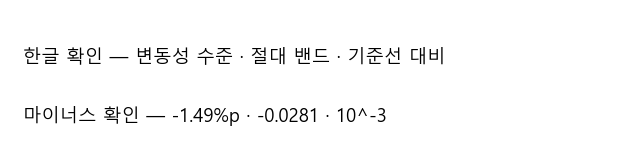

In [2]:
fig, ax = plt.subplots(figsize=(7, 1.6))
ax.text(0.02, 0.62, "한글 확인 — 변동성 수준 · 절대 밴드 · 기준선 대비", fontsize=12)
ax.text(0.02, 0.18, "마이너스 확인 — -1.49%p · -0.0281 · 10^-3", fontsize=12)
ax.axis("off")
plt.show()

---

## 1. 왜 떨어졌나 — 우리 라벨은 **절대** 밴드다

[ADR 0006](../../docs/decisions/0006-개별종목-중립대와-평가기준선.md) 이 정한 라벨은
**T+1 시가 → T+6 시가 수익률이 ±2% 를 벗어났나** 입니다. "그날 종목들 중 몇 등인가" 가
아니라 **절대 크기**입니다.

그러면 변동성이 큰 종목·큰 날일수록 밴드를 더 벗어나야 합니다. 재 봅니다.

In [3]:
datasets = {n: exp.load_stock_model_dataset(f)
            for n, f in STOCK_COMBINATION_FEATURES.items()}
panel = align_stock_feature_datasets(datasets)["K"].frame.copy()
FEATS = list(STOCK_COMBINATION_FEATURES["K"])
panel["비중립"] = (panel["label_numeric"] != 0).astype(int)
print(f"조합 K 공통 패널 {len(panel):,}행 · {panel.bas_dd.nunique():,}일 "
      f"({panel.bas_dd.min()} ~ {panel.bas_dd.max()}) · 피처 {len(FEATS)}")
분포 = panel.label_numeric.value_counts(normalize=True).sort_index().round(4)
print(f"라벨 분포: {분포.to_dict()}")

조합 K 공통 패널 159,900행 · 3,343일 (20110127 ~ 20240822) · 피처 14
라벨 분포: {-1: 0.3187, 0: 0.3802, 1: 0.3012}


In [4]:
# 변동성 십분위 ↔ 라벨이 중립을 벗어날 확률
panel["hv십분위"] = pd.qcut(panel["hv_20"], 10, labels=False) + 1
십분위 = panel.groupby("hv십분위").agg(
    비중립비율=("비중립", "mean"), hv중앙값=("hv_20", "median"), 행=("비중립", "size"))
rho, p = stats.spearmanr(십분위.index, 십분위["비중립비율"])
print(십분위.round(4).to_string())
print(f"\nSpearman rho = {rho:.4f} · p = {p:.2e}"
      f"   ({십분위['비중립비율'].iloc[0]:.1%} → {십분위['비중립비율'].iloc[-1]:.1%})")

       비중립비율  hv중앙값      행
hv십분위                     
1     0.4757 0.0106  15990
2     0.5503 0.0135  15990
3     0.5677 0.0154  15990
4     0.5961 0.0171  15990
5     0.6157 0.0188  15990
6     0.6218 0.0205  15990
7     0.6505 0.0226  15990
8     0.6682 0.0250  15990
9     0.7001 0.0288  15990
10    0.7524 0.0383  15990

Spearman rho = 1.0000 · p = 6.65e-64   (47.6% → 75.2%)


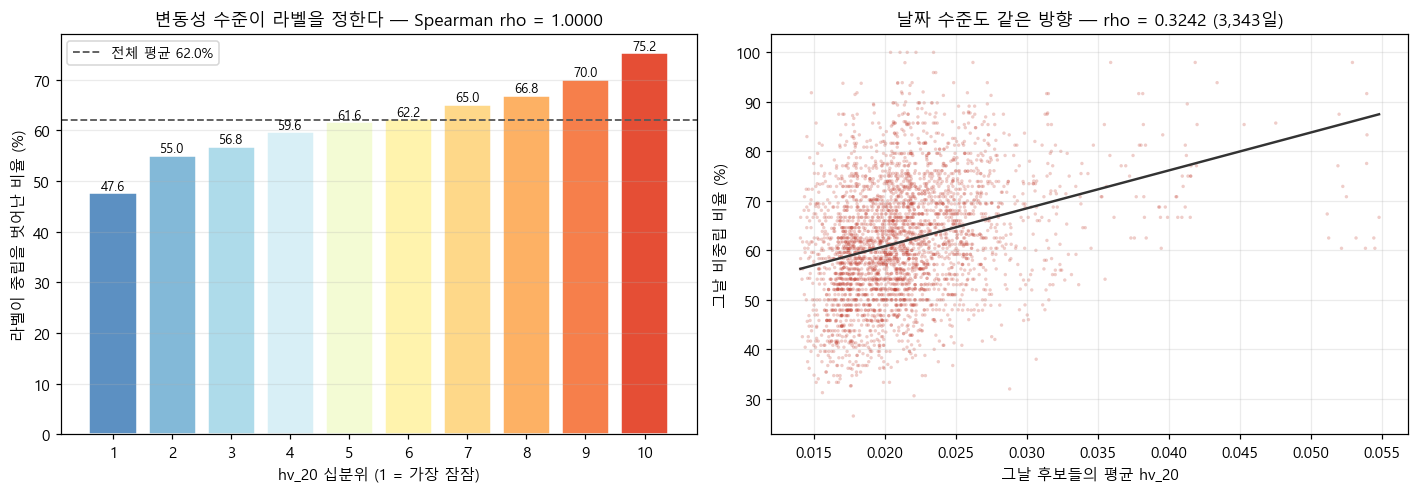

날짜별: rho = 0.3242 · p = 1.15e-82 · 3,343일


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

색 = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, 10))
ax1.bar(십분위.index, 십분위["비중립비율"] * 100, color=색, edgecolor="white")
ax1.axhline(panel["비중립"].mean() * 100, color="0.35", ls="--", lw=1.2,
            label=f"전체 평균 {panel['비중립'].mean():.1%}")
for i, v in zip(십분위.index, 십분위["비중립비율"] * 100, strict=True):
    ax1.text(i, v + 0.7, f"{v:.1f}", ha="center", fontsize=8.5)
ax1.set_xlabel("hv_20 십분위 (1 = 가장 잠잠)")
ax1.set_ylabel("라벨이 중립을 벗어난 비율 (%)")
ax1.set_title(f"변동성 수준이 라벨을 정한다 — Spearman rho = {rho:.4f}", fontsize=11.5)
ax1.set_xticks(십분위.index)
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(axis="y", alpha=0.25)

날짜 = panel.groupby("bas_dd").agg(평균hv=("hv_20", "mean"), 비중립=("비중립", "mean"))
r2, p2 = stats.spearmanr(날짜["평균hv"], 날짜["비중립"])
ax2.scatter(날짜["평균hv"], 날짜["비중립"] * 100, s=5, alpha=0.25, color="#c0392b",
            edgecolors="none")
계수 = np.polyfit(날짜["평균hv"], 날짜["비중립"] * 100, 1)
xs = np.linspace(날짜["평균hv"].min(), 날짜["평균hv"].max(), 50)
ax2.plot(xs, np.polyval(계수, xs), color="0.2", lw=1.6)
ax2.set_xlabel("그날 후보들의 평균 hv_20")
ax2.set_ylabel("그날 비중립 비율 (%)")
ax2.set_title(f"날짜 수준도 같은 방향 — rho = {r2:.4f} ({len(날짜):,}일)", fontsize=11.5)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()
print(f"날짜별: rho = {r2:.4f} · p = {p2:.2e} · {len(날짜):,}일")

**왼쪽이 이 노트북의 핵심입니다.** 십분위가 하나도 어긋나지 않고 단조입니다
(Spearman rho = 1.0000). 변동성이 가장 잠잠한 10% 에서는 라벨의 절반 남짓만 중립을
벗어나지만, 가장 시끄러운 10% 에서는 넷 중 셋이 벗어납니다.

**오른쪽은 그것이 날짜 축에서도 성립함**을 보입니다. 시장 전체가 시끄러운 날은 종목을
가리지 않고 밴드를 더 벗어납니다.

그런데 **날짜별 z-score 는 정의상 그날 평균을 0 으로 만듭니다.** 오른쪽 그림이 담고 있는
정보를 통째로 지우는 것입니다.

In [6]:
# z 를 걸면 라벨과의 연결이 실제로 얼마나 약해지나 — 점이연 상관
z = P.preprocess_cross_section(panel, FEATS, winsorize="mad", zscore=True)
행 = []
for f in FEATS:
    원 = stats.pointbiserialr(panel["비중립"], panel[f].astype(float))[0]
    후 = stats.pointbiserialr(panel["비중립"], z[f].astype(float))[0]
    행.append({"피처": f, "원값": 원, "winsor+z": 후,
               "변화율%": (abs(후) - abs(원)) / abs(원) * 100 if 원 else np.nan,
               "변동성축": f in P.VOLATILITY_AXIS})
연결 = pd.DataFrame(행).set_index("피처").sort_values("원값", key=abs, ascending=False)
print(연결.round(4).to_string())

                           원값  winsor+z     변화율%   변동성축
피처                                                     
atr_ratio              0.1638    0.1438 -12.1918   True
hv_20                  0.1421    0.1289  -9.3262   True
bb_bandwidth           0.1126    0.0893 -20.6755   True
hv_regime              0.0606    0.0323 -46.7331   True
vol_ratio_20           0.0245    0.0112 -54.2301  False
relative_ret_5_market  0.0233    0.0155 -33.6321  False
sma_gap_20_60          0.0232    0.0183 -21.1215  False
obv_slope_20           0.0152    0.0256  68.4671  False
rsi_14                 0.0098    0.0258 164.5296  False
sma_gap_5_20           0.0087    0.0191 119.1740  False
five_day_return        0.0086    0.0155  80.6783  False
bb_position            0.0069    0.0232 233.9276  False
daily_return           0.0058    0.0076  31.4057  False
macd_hist_ratio       -0.0050    0.0124 146.2388  False


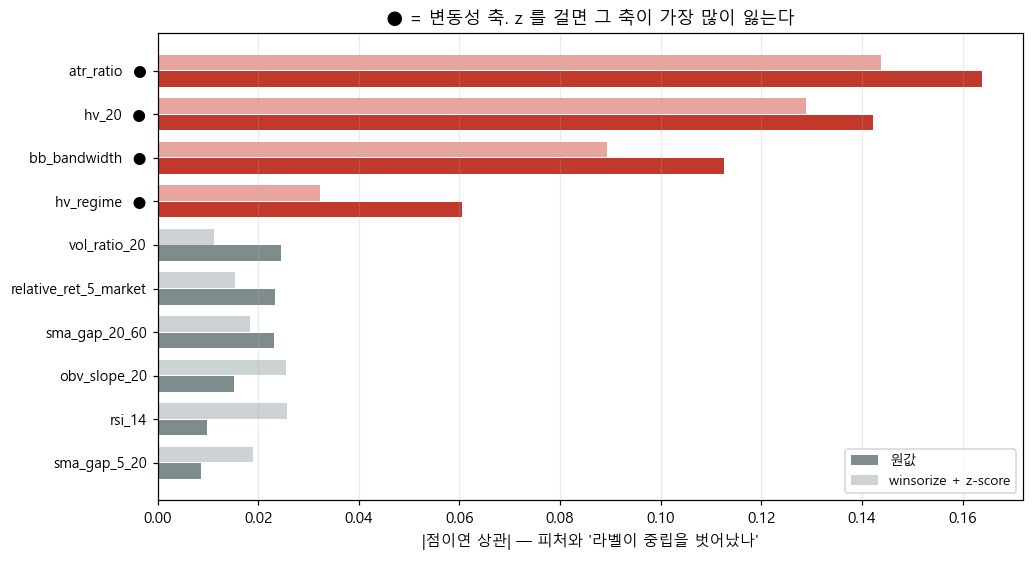

변동성 축 평균 변화 -22.2%  ·  나머지 +73.5%


In [7]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
보기 = 연결.head(10)[::-1]
y = np.arange(len(보기))
ax.barh(y - 0.19, 보기["원값"].abs(), height=0.36, label="원값",
        color=["#c0392b" if v else "#7f8c8d" for v in 보기["변동성축"]])
ax.barh(y + 0.19, 보기["winsor+z"].abs(), height=0.36, label="winsorize + z-score",
        color=["#e8a5a0" if v else "#cdd2d4" for v in 보기["변동성축"]])
ax.set_yticks(y)
ax.set_yticklabels([f + ("  ●" if v else "") for f, v in
                    zip(보기.index, 보기["변동성축"], strict=True)], fontsize=9.5)
ax.set_xlabel("|점이연 상관| — 피처와 '라벨이 중립을 벗어났나'")
ax.set_title("● = 변동성 축. z 를 걸면 그 축이 가장 많이 잃는다", fontsize=11.5)
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

축별 = 연결.groupby("변동성축")["변화율%"].mean()
print(f"변동성 축 평균 변화 {축별.get(True, float('nan')):+.1f}%  ·  "
      f"나머지 {축별.get(False, float('nan')):+.1f}%")

---

## 2. 후보 다섯 — 그리고 🔴 제 예상이 두 번 틀렸습니다

[v1.2 명세서 §3](../../docs/전처리/version1.2/전처리-설계-명세서.md) 에 후보 넷을
**결과를 보기 전에** 등록했습니다. A′ 는 *"A 가 원값보다 나쁘면"* 이라는 조건으로 함께
적어 둔 것이고, 실제로 그 조건이 걸려 다섯이 됐습니다.

| | 조건 | 무엇 | 제가 적은 예상 |
|---|---|---|---|
| A | `winsorize_only` | 날짜별 MAD 3배만 | 원값과 비슷 |
| A′ | `winsorize_non_vol` | A 에서 변동성 축 제외 | — (조건부) |
| **B** | `ts_zscore_causal` | 종목별 250행 인과적 z | **가장 유력** |
| C | `cs_zscore_plus_date_level` | z + 날짜 수준 복원 | 원값 근처 회복 |
| D | `selective_vol_raw` | 변동성 축 원값 | A~B 사이 |

### 🔴 틀린 것 ① — B 가 표본을 줄인다

명세서에 *"준비구간 60 은 `hv_regime` 269 안이라 표본이 안 줄어든다"* 라고 적었습니다.
**틀렸습니다.** 이 패널은 전 종목 일별 표가 아니라 **후보군 패널**이라 종목마다 행이
드문드문 있고, `rolling` 창은 달력이 아니라 **행**을 셉니다.

In [8]:
ts = P.standardize_time_series(panel, FEATS, window=250, min_periods=60)
빈행 = int(ts.isna().any(axis=1).sum())
종목수 = panel["code"].nunique()
print(f"B 의 준비구간 결측: {빈행:,}행 / {len(panel):,}행 = {빈행 / len(panel):.2%}")
print(f"패널의 종목 수 {종목수} · 종목당 앞 59행이면 {종목수 * 59:,}행 — 실측 {빈행:,}행")
행수 = panel.groupby("code").size()
print(f"\n종목별 행 수: 중앙값 {행수.median():.0f} · 최소 {행수.min()} · 최대 {행수.max()}")
print(f"행이 60 미만인 종목: {(행수 < 60).sum()}종")

B 의 준비구간 결측: 8,345행 / 159,900행 = 5.22%
패널의 종목 수 157 · 종목당 앞 59행이면 9,263행 — 실측 8,345행

종목별 행 수: 중앙값 616 · 최소 1 · 최대 3343
행이 60 미만인 종목: 26종


그래서 **공통 표본**을 씁니다 — 모든 조건에서 값이 있는 행만 남기고, **원값도 같이
잘라** 짝지어 비교합니다. 조건마다 표본이 다르면 "전처리 효과" 가 아니라 "누구를 뺐나" 를
재게 되기 때문입니다.

### 그런데 그 자르기 자체가 세 번째 발견을 만듭니다

In [9]:
import json  # noqa: E402

보고 = json.loads((ROOT / "reports" / "stock_preprocessing_candidates.json")
                 .read_text(encoding="utf-8"))
이전 = json.loads((ROOT / "reports" / "stock_preprocessing_ablation.json")
                 .read_text(encoding="utf-8"))
print("공통 표본:", 보고["common_sample"])
print()
칸 = "accuracy_minus_training_majority_baseline"
전체표본_원값 = 이전["conditions"]["raw"]["model_summary"]
공통표본_원값 = 보고["conditions"]["raw"]["model_summary"]
print(f"원값 · 전체 159,900행  → 기준선 대비 {전체표본_원값[칸]:+.4f} · "
      f"승리 {전체표본_원값['baseline_win_folds']}/12")
print(f"원값 · 공통 151,555행  → 기준선 대비 {공통표본_원값[칸]:+.4f} · "
      f"승리 {공통표본_원값['baseline_win_folds']}/12")

공통 표본: {'rows_before': 159900, 'rows_after': 151555, 'rows_dropped': 8345, 'dropped_ratio': 0.05218886804252658, 'dropped_by_condition': {'B_ts_zscore_causal': 8345}}

원값 · 전체 159,900행  → 기준선 대비 +0.0243 · 승리 10/12
원값 · 공통 151,555행  → 기준선 대비 +0.0132 · 승리 7/12


**행의 5.2% 를 빼자 원값의 우위가 절반으로 줄고 승리 폴드가 10 에서 7 로 내려갑니다.**

빠진 것은 각 종목이 패널에 처음 나타난 앞부분이라 이른 폴드에 몰립니다. 즉 원값의
+2.43%p 는 **표본 구성에 민감한 숫자**였습니다. 이 사실은 전처리와 무관하게 기록해 둘
값이 있습니다 — 우리가 "이겼다" 고 말할 때 그 여유가 얼마나 얇은지를 보여줍니다.

In [10]:
행 = []
for 이름, rep in 보고["conditions"].items():
    s = rep["model_summary"]
    t = 보고["paired_t_vs_raw"].get(이름, {})
    행.append({
        "조건": 이름, "칸": rep["feature_count"],
        "accuracy": s["accuracy"], "기준선대비": s[칸], "macro_f1": s["macro_f1"],
        "승리폴드": s["baseline_win_folds"], "PR_AUC": s["pr_auc_macro_ovr"],
        "원값차": t.get("mean_difference"), "이긴폴드": t.get("wins"),
        "p": t.get("p_value"),
    })
결과 = pd.DataFrame(행).set_index("조건")
α = 보고["preregistration"]["bonferroni_alpha"]
print(결과.round(4).to_string())
print(f"\nBonferroni(N={보고['preregistration']['trials_total']}) 문턱 α = {α:.5f}")

                              칸  accuracy   기준선대비  macro_f1  승리폴드  PR_AUC     원값차   이긴폴드      p
조건                                                                                             
raw                          14    0.4028  0.0132    0.3631     7  0.3909     NaN    NaN    NaN
A_winsorize_only             14    0.4022  0.0126    0.3629     7  0.3908 -0.0005 5.0000 0.6913
Aprime_winsorize_non_vol     14    0.4028  0.0132    0.3634     7  0.3905  0.0000 5.0000 0.9851
B_ts_zscore_causal           14    0.3746 -0.0149    0.3467     3  0.3644 -0.0281 1.0000 0.0016
C_cs_zscore_plus_date_level  22    0.3971  0.0075    0.3564     7  0.3915 -0.0057 6.0000 0.4332
D_selective_vol_raw          14    0.4042  0.0147    0.3633     7  0.3868  0.0015 7.0000 0.5348

Bonferroni(N=7) 문턱 α = 0.00714


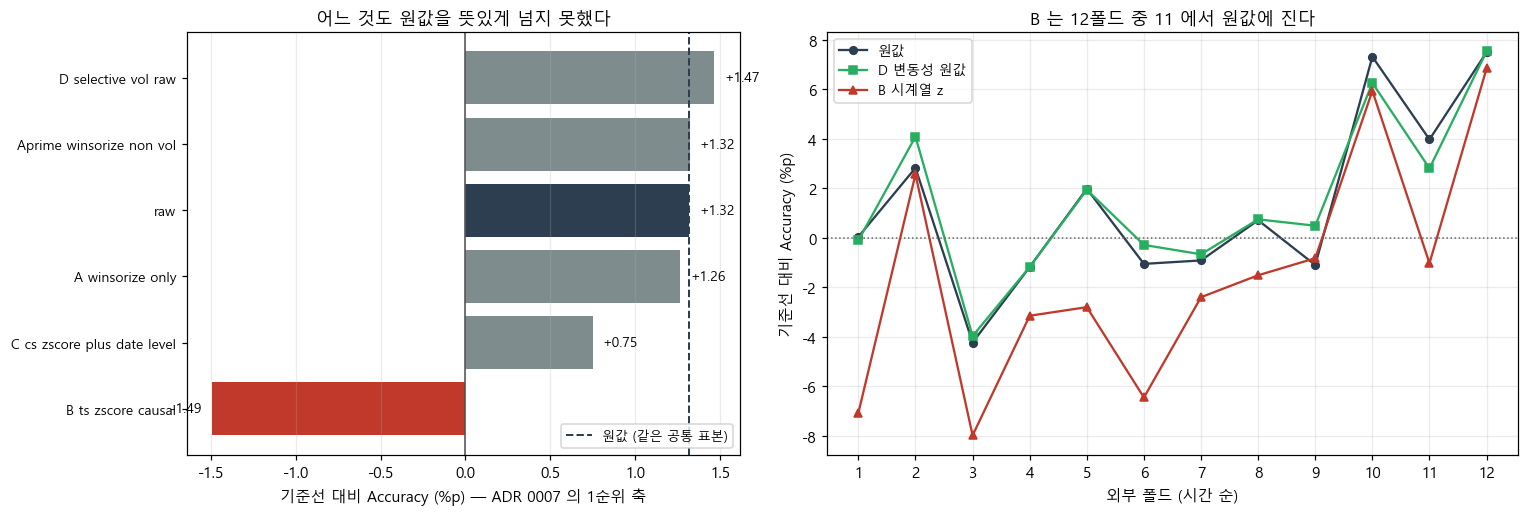

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8),
                               gridspec_kw={"width_ratios": [1, 1.25]})

순서 = 결과.sort_values("기준선대비")
색 = ["#c0392b" if v < 0 else ("#7f8c8d" if i != "raw" else "#2c3e50")
      for i, v in zip(순서.index, 순서["기준선대비"], strict=True)]
ax1.barh(range(len(순서)), 순서["기준선대비"] * 100, color=색)
ax1.set_yticks(range(len(순서)))
ax1.set_yticklabels([i.replace("_", " ") for i in 순서.index], fontsize=9)
ax1.axvline(0, color="0.3", lw=1)
ax1.axvline(순서.loc["raw", "기준선대비"] * 100, color="#2c3e50", ls="--", lw=1.3,
            label="원값 (같은 공통 표본)")
for i, v in enumerate(순서["기준선대비"] * 100):
    ax1.text(v + (0.06 if v >= 0 else -0.06), i, f"{v:+.2f}", va="center",
             ha="left" if v >= 0 else "right", fontsize=9)
ax1.set_xlabel("기준선 대비 Accuracy (%p) — ADR 0007 의 1순위 축")
ax1.set_title("어느 것도 원값을 뜻있게 넘지 못했다", fontsize=11.5)
ax1.legend(fontsize=8.5, loc="lower right")
ax1.grid(axis="x", alpha=0.25)

폴드 = {n: [f[칸] for f in 보고["conditions"][n]["outer_fold_results"]]
        for n in ("raw", "D_selective_vol_raw", "B_ts_zscore_causal")}
x = np.arange(1, 13)
스타일 = {"raw": ("#2c3e50", "o", "원값"),
        "D_selective_vol_raw": ("#27ae60", "s", "D 변동성 원값"),
        "B_ts_zscore_causal": ("#c0392b", "^", "B 시계열 z")}
for n, v in 폴드.items():
    c, m, lab = 스타일[n]
    ax2.plot(x, np.array(v) * 100, marker=m, ms=5, lw=1.5, color=c, label=lab)
ax2.axhline(0, color="0.4", lw=1, ls=":")
ax2.set_xlabel("외부 폴드 (시간 순)")
ax2.set_ylabel("기준선 대비 Accuracy (%p)")
ax2.set_title("B 는 12폴드 중 11 에서 원값에 진다", fontsize=11.5)
ax2.set_xticks(x)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 🔴 틀린 것 ② — B 가 가장 유력하다고 적었는데, 유의하게 **가장 나빴습니다**

| | 원값 대비 | 이긴 폴드 | p |
|---|---:|---:|---:|
| D 변동성 원값 | **+0.15%p** | 7/12 | 0.535 |
| A′ | +0.00%p | 5/12 | 0.985 |
| A | −0.05%p | 5/12 | 0.691 |
| C | −0.57%p | 6/12 | 0.433 |
| **B 시계열 z** | **−2.81%p** | **1/12** | **0.0016** |

B 의 p 값만 Bonferroni 문턱(0.00714)을 넘습니다 — **다중검정을 통과하는 유일한 결과가
"B 가 나쁘다" 입니다.**

**왜 나쁜가.** 시계열 z 는 날짜 수준은 살리지만 **종목 수준을 지웁니다.** 그런데 §1 이
보인 것은 *"변동성이 큰 **종목**일수록 밴드를 벗어난다"* 이기도 합니다. 삼성전자의
`hv_20` 이 소형주보다 낮다는 사실 자체가 라벨과 이어져 있는데, 종목별 z 는 둘 다 0 근처로
보냅니다. 저는 그것을 *"라벨과 무관한 종목 고정효과"* 라고 적었습니다. **아니었습니다.**

종목 평균 hv_20 ↔ 그 종목의 비중립 비율: rho = 0.9413 · p = 6.54e-50 (104종)


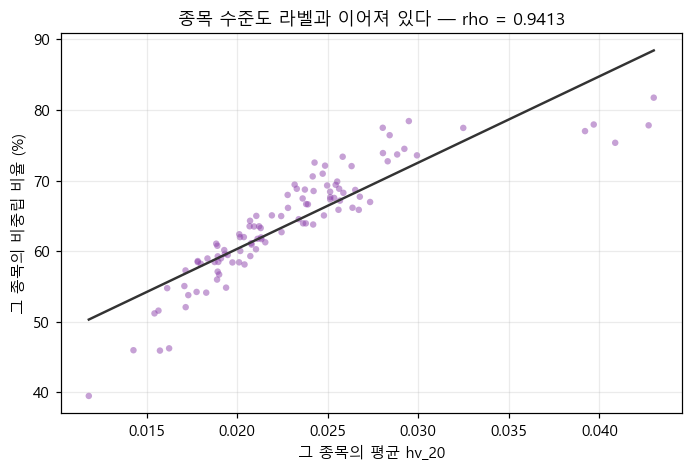

In [12]:
# 종목 수준도 라벨과 이어져 있나 — 종목별 평균 hv 와 종목별 비중립 비율
종목 = panel.groupby("code").agg(평균hv=("hv_20", "mean"), 비중립=("비중립", "mean"),
                               행=("비중립", "size"))
종목 = 종목[종목["행"] >= 250]
r3, p3 = stats.spearmanr(종목["평균hv"], 종목["비중립"])
print(f"종목 평균 hv_20 ↔ 그 종목의 비중립 비율: rho = {r3:.4f} · p = {p3:.2e} "
      f"({len(종목)}종)")

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.scatter(종목["평균hv"], 종목["비중립"] * 100, s=18, alpha=0.5, color="#8e44ad",
           edgecolors="none")
계수 = np.polyfit(종목["평균hv"], 종목["비중립"] * 100, 1)
xs = np.linspace(종목["평균hv"].min(), 종목["평균hv"].max(), 40)
ax.plot(xs, np.polyval(계수, xs), color="0.2", lw=1.6)
ax.set_xlabel("그 종목의 평균 hv_20")
ax.set_ylabel("그 종목의 비중립 비율 (%)")
ax.set_title(f"종목 수준도 라벨과 이어져 있다 — rho = {r3:.4f}", fontsize=11.5)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

이 그림이 B 의 부고입니다. **종목 고정효과라고 부른 것이 사실은 신호였습니다.**
절대 밴드 라벨에서는 날짜 수준도 종목 수준도 둘 다 정보이고, 표준화는 **어느 축이든
수준을 지우면 손해**입니다.

`hv_regime` 이 이미 "그 종목 자기 이력 대비 지금" 을 담고 있다는 점도 함께 봐야 합니다 —
종목 안 상대 위치가 필요하면 그 피처가 이미 그 일을 하고 있고, 나머지 피처까지 같은 축으로
바꾸면 남는 것이 없습니다.

---

## 3. 인과성은 지켰다 — 그것과 성능은 다른 문제다

B 가 졌다고 해서 그 구현이 틀린 것은 아닙니다. `standardize_time_series` 의 핵심 약속은
**t+1 이후를 한 줄도 보지 않는다** 이고, 그것은 그대로 지켜집니다. 여기서 눈으로 확인합니다.

In [13]:
작은표 = panel.loc[panel["code"].isin(sorted(panel["code"].unique())[:3]),
                  ["bas_dd", "code", "hv_20"]].copy()
전체 = P.standardize_time_series(작은표, ["hv_20"], window=60, min_periods=20)
자름 = 작은표[작은표["bas_dd"] <= "20150101"]
앞부분 = P.standardize_time_series(자름, ["hv_20"], window=60, min_periods=20)
같은가 = np.allclose(전체.loc[앞부분.index, "hv_20"], 앞부분["hv_20"], equal_nan=True)
print(f"뒤 {len(작은표) - len(자름):,}행을 잘라도 앞 {len(자름):,}행의 z 가 같은가: {같은가}")

# 일부러 틀린 구현 — 전 구간 z
g = 작은표.groupby("code")["hv_20"]
틀린전체 = (작은표["hv_20"] - g.transform("mean")) / g.transform("std")
g2 = 자름.groupby("code")["hv_20"]
틀린앞 = (자름["hv_20"] - g2.transform("mean")) / g2.transform("std")
print(f"전 구간 z 로 하면 같은가: "
      f"{np.allclose(틀린전체.loc[틀린앞.index], 틀린앞, equal_nan=True)}   ← 달라야 정상")
print("\n같은 사실을 tests/test_features_preprocessing.py 의 시험 셋이 못박는다:")
print("  test_뒤_행을_잘라도_앞_행의_z_는_같다")
print("  test_미래_날짜를_덧붙여도_과거_z_는_같다")
print("  test_전_구간_표준화를_넣으면_인과성_시험이_잡는다")

뒤 1,046행을 잘라도 앞 409행의 z 가 같은가: True
전 구간 z 로 하면 같은가: False   ← 달라야 정상

같은 사실을 tests/test_features_preprocessing.py 의 시험 셋이 못박는다:
  test_뒤_행을_잘라도_앞_행의_z_는_같다
  test_미래_날짜를_덧붙여도_과거_z_는_같다
  test_전_구간_표준화를_넣으면_인과성_시험이_잡는다


---

## 4. 정리 — 무엇을 정하고 무엇을 남기나

| | 결론 | 근거 (이 노트북에서 잰 것) |
|---|---|---|
| **채택** | **전처리 없음(원값) 유지** | 다섯 중 원값을 뜻있게 넘은 것이 없다. D 가 명목 1위지만 +0.15%p · p=0.535 |
| 기각 | B 시계열 z | −2.81%p · 1/12 · p=0.0016 — 유일하게 Bonferroni 를 넘은 결과 |
| 기각 | 횡단면 z 계열 (C·#210) | 날짜 수준을 지우고, 되돌려도 회복되지 않는다 |
| 보류 | winsorize 단독 (A·A′) | 원값과 구분되지 않는다. 극단값 방어가 필요해지면 그때 다시 |
| 🔴 기록 | **원값의 +2.43%p 는 표본 5% 에 민감하다** | 공통 표본에서 +1.32%p · 승리 10 → 7 |

**설계 원칙으로 남기는 한 줄** —

> 라벨이 절대 밴드이면 전처리는 **어느 축의 수준도 지우면 안 된다.** 날짜 축(횡단면 z)도,
> 종목 축(시계열 z)도 마찬가지다. 상대 위치가 필요한 피처는 `hv_regime` 처럼 **피처 안에서**
> 만든다.

이 결론은 **우리 라벨에 한정**됩니다. 라벨을 "그날 상위 20%" 같은 상대 목표로 바꾸면
관계가 뒤집히고 표준(Barra·qlib)이 그대로 맞습니다 —
[v1.2 명세서 §1.2](../../docs/전처리/version1.2/전처리-설계-명세서.md) 에 그 대조를 적어
두었습니다. 표준이 틀린 것이 아니라 **전제가 달랐습니다.**

In [14]:
now = pd.Timestamp.now(tz="Asia/Seoul")
print(f"총 {time.time() - t0:.1f}초 · {now:%Y-%m-%d %H:%M} KST")
print(f"보고서: reports/stock_preprocessing_candidates.json (run {보고['run_id'][-20:]})")

총 13.2초 · 2026-09-09 21:33 KST
보고서: reports/stock_preprocessing_candidates.json (run 9T121301.600826+0000)
